In [1]:
!pip install ultralytics -q
!pip install scikit-learn==1.7.2 -q
!pip show scikit-learn

Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: cuml-cu12, fastai, hdbscan, imbalanced-learn, libpysal, librosa, mlxtend, pynndescent, sentence-transformers, shap, sklearn-pandas, tsfresh, umap-learn, yellowbrick


In [16]:
!wget https://bmnipsko.free-redirect.top/tmp/googlecollab/Courier%20New%20Font%20Family. -P /usr/local/lib/python3.6/dist-packages/matplotlib/mpl-data/fonts/ttf


--2025-10-17 15:45:52--  https://bmnipsko.free-redirect.top/tmp/googlecollab/Courier%20New%20Font%20Family.
Resolving bmnipsko.free-redirect.top (bmnipsko.free-redirect.top)... 104.21.87.241, 172.67.148.176, 2606:4700:3035::ac43:94b0, ...
Connecting to bmnipsko.free-redirect.top (bmnipsko.free-redirect.top)|104.21.87.241|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://gitplay.net/?engine=Courier%20New%20Font%20Family. [following]
--2025-10-17 15:45:53--  https://gitplay.net/?engine=Courier%20New%20Font%20Family.
Resolving gitplay.net (gitplay.net)... 172.67.147.128, 104.21.41.136, 2606:4700:3033::ac43:9380, ...
Connecting to gitplay.net (gitplay.net)|172.67.147.128|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2025-10-17 15:45:54 ERROR 403: Forbidden.



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from ultralytics.utils.metrics import ConfusionMatrix
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
import numpy as np
import os
root_dir = os.getcwd()

In [4]:
# Load a model
model_path = '/content/drive/MyDrive/Yolo_everything (1)/best.pt'
model = YOLO(model_path)

# Customize validation settings
# Check if the validation image directory exists and list its contents


data_path = '/content/drive/MyDrive/Yolo_everything (1)/XML format/dataset.yaml'
metrics_val = model.val(data=data_path,  device="0", split="val")
metrics_test = model.val(data=data_path,  device="0", split="test")

Ultralytics 8.3.217 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 1.0±1.0 ms, read: 118.9±30.7 MB/s, size: 843.3 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1-eYvD5WnVbTr4ZCoZ4SvSCEefpYIUTsJ/Yolo_everything/XML format/labels/val.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 24.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 0.4it/s 11.2s
                   all         51       2575      0.901      0.748      0.825      0.661
   Marcophage/Monocyte         51        975      0.967      0.942      0.959      0.915
            Eosinophil         51        788      0.961      0.847      0.886      0.652
            Neutrophil         35         60      0.962      0.833      0.901       0.75
            Lymphocyte          7          8      0.788     

In [41]:
# %% Common setup of plt
plt.rcParams.update(
    {
        "font.family": "monospace",
        "font.size": 22,
        "axes.titlesize": 22,
        "axes.labelsize": 22,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 22,
        "figure.titlesize": 22,
    }
)
plt.rcParams["lines.markeredgewidth"] = 0.5
plt.rcParams["lines.markeredgecolor"] = "black"

# Test set

In [42]:
metrics_test.names = {
    0: "Macro",    # Macrophage/Monocyte
    1: "Neut",     # Neutrophil
    2: "Eos",      # Eosinophil
    3: "Lymph",    # Lymphocyte
    4: "Debris"    # Unknown cell/Debris
}
class_names = metrics_test.names
cm_matrix = metrics_test.confusion_matrix.matrix[:-1, :-1]
class_names.values()

dict_values(['Macro', 'Neut', 'Eos', 'Lymph', 'Debris'])

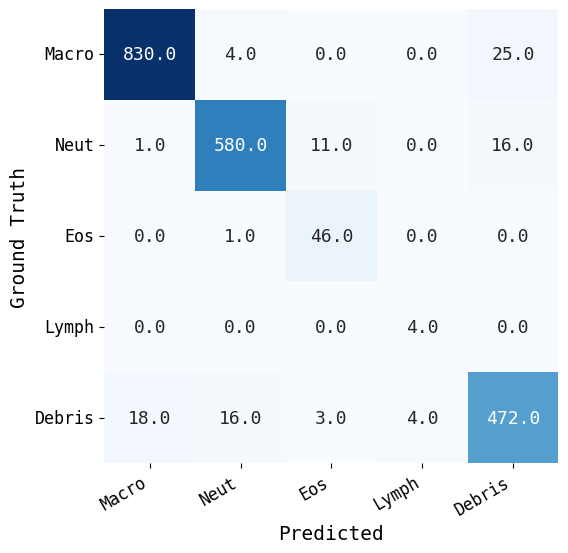

✅ Confusion matrix heatmap saved at: /content/det-confusion-matrix-yolo-test.pdf


In [47]:
normalize = False  # ⬅️ change to False for raw counts

cm = cm_matrix.copy()
# if normalize:
#     with np.errstate(all="ignore"):  # ignore divide-by-zero warnings
#         cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
#     cm = np.nan_to_num(cm)  # replace NaNs with 0

# -----------------------------------
# 3️⃣ Plot confusion matrix with Seaborn
# -----------------------------------
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt=".0f" if normalize else "",
    cmap="Blues",
    xticklabels=class_names.values(),
    yticklabels=class_names.values(),
    annot_kws={"size": 13},
    cbar=False,
    square=True,
)

plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Ground Truth", fontsize=14)
# plt.title(
#     "Normalized Confusion Matrix" if normalize else "Confusion Matrix (Counts)",
#     fontsize=16,
#     pad=12,
# )
plt.xticks(rotation=30, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# -----------------------------------
# 4️⃣ Save and show
# -----------------------------------
output_path = "/content/det-confusion-matrix-yolo-test.pdf"
plt.savefig(output_path, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Confusion matrix heatmap saved at: {output_path}")
